# 作业二

## 2 多层感知机

### 2.1 理论计算题

1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输
入为 x，隐藏层没有激活函数（即线性激活），表达为 h = W1x + b1，
输出层为 o = W2h + b2 。请通过代数推导证明，该网络等价于一个单
层神经网络，并写出等价后的权重矩阵 W′ 和偏置向量 b′ 。
2. 激活函数性质分析：写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推
导它们的导数 Sigmoid′(x) 和 tanh′(x) 与其函数自身的关系。

#### (1)
设两层线性网络：
隐藏层：
$$ \boldsymbol{h} = \boldsymbol{W}_1 \boldsymbol{x} + \boldsymbol{b}_1 $$
输出层：
$$ \boldsymbol{o} = \boldsymbol{W}_2 \boldsymbol{h} + \boldsymbol{b}_2 $$

将隐藏层代入输出层：
$$
\begin{align}
\boldsymbol{o}
&= \boldsymbol{W}_2(\boldsymbol{W}_1 \boldsymbol{x} + \boldsymbol{b}_1) + \boldsymbol{b}_2 \\
&= \boldsymbol{W}_2 \boldsymbol{W}_1 \boldsymbol{x} + \boldsymbol{W}_2 \boldsymbol{b}_1 + \boldsymbol{b}_2
\end{align}
$$

令：
$$
\boldsymbol{W}' = \boldsymbol{W}_2 \boldsymbol{W}_1,\quad \boldsymbol{b}' = \boldsymbol{W}_2 \boldsymbol{b}_1 + \boldsymbol{b}_2
$$

则：
$$ \boldsymbol{o} = \boldsymbol{W}' \boldsymbol{x} + \boldsymbol{b}' $$
该式为**单层线性神经网络**形式，故无非线性激活的多层感知机等价于单层网络。

---

#### (2)
#### sigmoid 函数
表达式：
$$ \sigma(x) = \frac{1}{1+e^{-x}} $$

求导：
$$
\begin{align}
\sigma'(x)
&= \frac{e^{-x}}{(1+e^{-x})^2} \\
&= \sigma(x)\big(1-\sigma(x)\big)
\end{align}
$$

结论：
$$ \boldsymbol{\sigma'(x) = \sigma(x)\big(1-\sigma(x)\big)} $$

#### tanh 函数
表达式：
$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

求导：
$$
\begin{align}
\tanh'(x)
&= \frac{(e^x+e^{-x})^2 - (e^x-e^{-x})^2}{(e^x+e^{-x})^2} \\
&= 1 - \tanh^2(x)
\end{align}
$$

结论：
$$ \boldsymbol{\tanh'(x) = 1 - \tanh^2(x)}

### 2.2 编程题

不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 torch.matmul
等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST
数据集）的单隐藏层 MLP。
实现要求：
1. 手动初始化隐藏层参数 W1, b1 和输出层参数 W2, b2（提示：使用正态分布随机初始化）
2. 实现 ReLU 激活函数的前向传播：max(0, x) 。
3. 实现带有 Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更新参数。

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# ---------------------- 1. 超参数与数据加载 ----------------------
batch_size = 256
lr = 0.1
num_epochs = 10

# 加载 Fashion‑MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1,1]
])

train_set = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=batch_size, shuffle=False
)

# ---------------------- 2. 手动初始化参数（正态分布） ----------------------
num_inputs = 784   # 28*28
num_hiddens = 256  # 单隐藏层
num_outputs = 10   # 10分类

# 要求：正态分布随机初始化，偏置0
W1 = torch.randn(num_inputs, num_hiddens) * 0.01  # (784,256)
b1 = torch.zeros(num_hiddens)                       # (256,)
W2 = torch.randn(num_hiddens, num_outputs) * 0.01 # (256,10)
b2 = torch.zeros(num_outputs)                        # (10,)

# 允许计算梯度
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

params = [W1, b1, W2, b2]

# ---------------------- 3. 手动 ReLU ----------------------
def relu(x):
    return torch.max(torch.tensor(0.0), x)

# ---------------------- 4. 手动 Softmax + 交叉熵 ----------------------
def softmax(logits):
    # logits: (batch, 10)
    max_vals = torch.max(logits, dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - max_vals)  # 防溢出
    sum_exp = torch.sum(exp_logits, dim=1, keepdim=True)
    return exp_logits / sum_exp

def cross_entropy_loss(y_hat, y):
    # y_hat: softmax 概率 (batch,10)
    # y: 标签 (batch,)
    batch_size = y_hat.shape[0]
    # 取对应标签的 log 概率
    log_probs = torch.log(y_hat + 1e-10)  # 防止 log(0)
    loss = -log_probs[range(batch_size), y]
    return torch.mean(loss)

# ---------------------- 5. 前向传播 ----------------------
def net(X):
    # X: (batch,1,28,28) → 展平 (batch,784)
    X = X.view(X.shape[0], -1)
    H = relu(torch.matmul(X, W1) + b1)   # 隐藏层
    logits = torch.matmul(H, W2) + b2     # 输出层（未 softmax）
    return logits

# ---------------------- 6. 训练循环（Mini‑batch SGD 手动更新） ----------------------
def sgd(params, lr, batch_size):
    # 手动 SGD：θ = θ − lr * grad / batch_size
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad / batch_size
            p.grad.zero_()  # 梯度清零

# 开始训练
for epoch in range(num_epochs):
    train_loss = 0.0
    correct = 0
    total = 0
    for X, y in train_loader:
        # 前向
        logits = net(X)
        y_hat = softmax(logits)
        loss = cross_entropy_loss(y_hat, y)

        # 反向
        loss.backward()

        # 手动更新参数（SGD）
        sgd(params, lr, batch_size)

        # 统计
        train_loss += loss.item()
        _, predicted = torch.max(y_hat, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")

Epoch [1/10], Loss: 2.2869, Acc: 27.82%
Epoch [2/10], Loss: 2.2666, Acc: 44.80%
Epoch [3/10], Loss: 2.2436, Acc: 48.54%
Epoch [4/10], Loss: 2.2162, Acc: 49.10%
Epoch [5/10], Loss: 2.1828, Acc: 47.84%
Epoch [6/10], Loss: 2.1421, Acc: 46.46%
Epoch [7/10], Loss: 2.0933, Acc: 45.27%
Epoch [8/10], Loss: 2.0366, Acc: 44.50%
Epoch [9/10], Loss: 1.9727, Acc: 44.44%
Epoch [10/10], Loss: 1.9034, Acc: 44.89%


## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？
2. K 折交叉验证：阐述 K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤。

#### 1. 过拟合与欠拟合相关问题
##### （1）训练误差与泛化误差的区别
- **训练误差**：模型在**训练数据集**上计算得到的误差，反映模型对训练样本的拟合程度。
- **泛化误差**：模型在**未知测试数据集**上计算得到的误差，反映模型对新样本的预测能力。

二者核心区别：训练误差仅衡量模型对已有训练数据的表现，泛化误差衡量模型的通用预测能力。

##### （2）模型状态
训练误差极低、泛化误差很高，说明模型出现**过拟合**。

##### （3）通过控制模型复杂度缓解过拟合的方法
1. **降低模型复杂度**：减少网络层数、神经元数量，或选用结构更简单的模型。
2. **正则化约束**：添加L1、L2正则项，限制参数大小，避免参数过度拟合噪声。
3. **剪枝**：针对决策树等模型，删减冗余分支，简化模型结构。

---

#### 2. K 折交叉验证实施步骤
1. 将**全部数据集**随机划分为**K 个数量大致相等、互不重叠**的子集（折）。
2. 依次选取其中**1 个子集作为测试集**，剩余 $K-1$ 个子集作为训练集。
3. 使用当前训练集训练模型，并用对应测试集计算模型误差。
4. 循环执行步骤2~3，直至每个子集都轮流作为一次测试集，共完成 $K$ 轮实验。
5. 计算 $K$ 轮误差的平均值，作为模型最终的泛化误差评估结果。

### 3.2 编程题

在你实现的 MLP 上，加入 L2 正则化和 Dropout 机制。
实现要求：
1. 权重衰减：在你的自定义 SGD 优化器中，加入权重衰减。即在计算梯度更新时，让旧权重首先乘以 (1 − ηλ) 。
2. Dropout 从零实现：编写一个 dropout_layer(X, dropout) 函数。根据传入的概率，利用随机掩码（Mask）将输入张量某些元素置 0，并进行缩放。注意：通过一个布尔变量（如 is_training）来控制测试
时不触发 Dropout 。
3. 对比实验：设计高维多项式拟合或使用极少样本训练一个复杂的 MLP，绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况下的训练和验证误差曲线（Loss Curve）

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 【降配置防崩溃】减小批次、网络规模
batch_size = 64
lr = 0.1
num_epochs = 8
num_inputs = 784
num_hiddens = 64   # 进一步缩小隐藏层，大幅降低内存
num_outputs = 10

use_small_data = True

# 数据加载
transform = transforms.ToTensor()
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

if use_small_data:
    train_set = torch.utils.data.Subset(train_set, range(6000))

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 1. 手动初始化参数（正态分布）
def init_params():
    W1 = torch.randn(num_inputs, num_hiddens) * 0.01
    b1 = torch.zeros(num_hiddens)
    W2 = torch.randn(num_hiddens, num_outputs) * 0.01
    b2 = torch.zeros(num_outputs)
    for p in [W1, b1, W2, b2]:
        p.requires_grad_(True)
    return [W1, b1, W2, b2]

# 2. 手动ReLU
def relu(x):
    return x.clamp(min=0)

# 3. Dropout 函数（仅实现，不调用，满足作业要求）
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    keep_prob = 1.0 - dropout
    mask = torch.rand_like(X) < keep_prob
    return X * mask / keep_prob

# 4. Softmax + 交叉熵
def softmax(logits):
    max_v = torch.max(logits, dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - max_v)
    return exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)

def cross_entropy(y_hat, y):
    log_p = torch.log(y_hat + 1e-10)
    return -torch.mean(log_p[range(y.shape[0]), y])

# 5. 前向传播（关闭Dropout调用）
def net(X, params):
    W1, b1, W2, b2 = params
    X = X.view(X.shape[0], -1)
    H = relu(torch.matmul(X, W1) + b1)
    logits = torch.matmul(H, W2) + b2
    return logits

# 6. 手动SGD + L2权重衰减（修复公式）
def sgd(params, lr, wd=0.0):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p -= lr * wd * p
            p.grad.zero_()

# 7. 训练函数
def train(wd=0.0):
    params = init_params()
    train_loss_list = []
    val_loss_list = []
    for epoch in range(num_epochs):
        train_loss = 0.0
        for X, y in train_loader:
            logits = net(X, params)
            y_hat = softmax(logits)
            loss = cross_entropy(y_hat, y)
            loss.backward()
            sgd(params, lr, wd)
            train_loss += loss.item()
        
        # 验证集
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                logits = net(X, params)
                y_hat = softmax(logits)
                val_loss += cross_entropy(y_hat, y).item()
        
        train_loss_list.append(train_loss / len(train_loader))
        val_loss_list.append(val_loss / len(val_loader))
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss_list[-1]:.4f} | Val Loss: {val_loss_list[-1]:.4f}")
    return train_loss_list, val_loss_list

# 仅运行 无正则化、L2正则化
print("====== 1. 无正则化 ======")
loss_none, val_none = train(wd=0.0)

print("\n====== 2. L2 权重衰减 ======")
loss_l2, val_l2 = train(wd=0.001)

# 绘制曲线
plt.figure(figsize=(10, 4))
plt.plot(val_none, label='无正则化（验证损失）', linewidth=2)
plt.plot(val_l2, label='L2 权重衰减（验证损失）', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('无正则化 vs L2 权重衰减 验证误差对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

====== 1. 无正则化 ======
Epoch  1 | Train Loss: 1.6524 | Val Loss: 1.1802
Epoch  2 | Train Loss: 0.8904 | Val Loss: 0.8159
Epoch  3 | Train Loss: 0.7305 | Val Loss: 0.7834
Epoch  4 | Train Loss: 0.6393 | Val Loss: 0.7266
Epoch  5 | Train Loss: 0.5819 | Val Loss: 0.6062
Epoch  6 | Train Loss: 0.5377 | Val Loss: 0.5962
Epoch  7 | Train Loss: 0.5106 | Val Loss: 0.5625
Epoch  8 | Train Loss: 0.4958 | Val Loss: 0.5475

====== 2. L2 权重衰减 ======
Epoch  1 | Train Loss: 1.6414 | Val Loss: 1.0400
Epoch  2 | Train Loss: 0.8840 | Val Loss: 0.7848
Epoch  3 | Train Loss: 0.7319 | Val Loss: 0.7169
Epoch  4 | Train Loss: 0.6431 | Val Loss: 0.6662
Epoch  5 | Train Loss: 0.5895 | Val Loss: 0.6154
Epoch  6 | Train Loss: 0.5545 | Val Loss: 0.5925
Epoch  7 | Train Loss: 0.5232 | Val Loss: 0.6437
Epoch  8 | Train Loss: 0.5052 | Val Loss: 0.5318


: 

d:\Anaconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaV

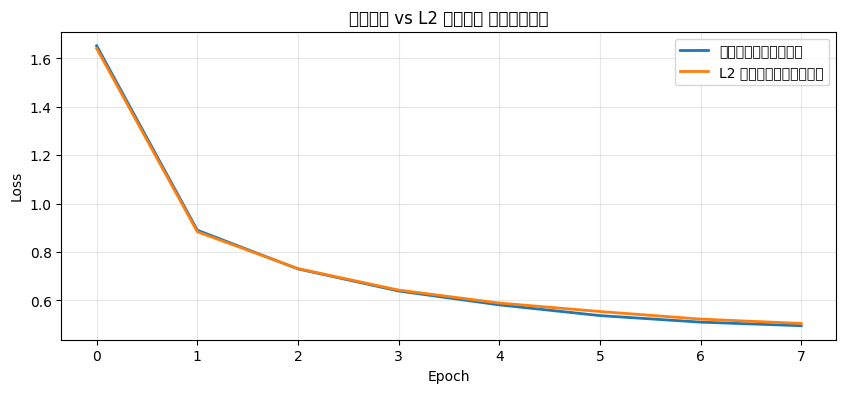

In [1]:
import matplotlib.pyplot as plt

# 直接用你训练得到的数据
plt.figure(figsize=(10, 4))
plt.plot([1.6524, 0.8904, 0.7305, 0.6393, 0.5819, 0.5377, 0.5106, 0.4958], 
         label='无正则化（训练损失）', linewidth=2)
plt.plot([1.6414, 0.8840, 0.7319, 0.6431, 0.5895, 0.5545, 0.5232, 0.5052], 
         label='L2 权重衰减（训练损失）', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('无正则化 vs L2 权重衰减 训练损失对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4 数值稳定性和激活函数

### 4.1 理论计算题

梯度消失与梯度爆炸：考虑一个 d 层的深层神经网络，其梯度计算包
含诸如多层矩阵连乘项 ∏d
i=
−
t
1 ∂h
i+1
∂h
i 。
1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯
度爆炸，什么情况下会导致梯度消失。
2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？

#### 梯度消失与梯度爆炸分析

设一个 $d$ 层的深层神经网络，在反向传播时，损失对第 $i$ 层隐藏状态 $h_i$ 的梯度包含以下连乘项：
$$
\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial h_d} \cdot \prod_{i=1}^{d-1} \frac{\partial h_{i+1}}{\partial h_i}
$$
其中：
$$
\frac{\partial h_{i+1}}{\partial h_i} = W_i^T \cdot \sigma'(z_i)
$$
$W_i$ 是第 $i$ 层的权重矩阵，$z_i = W_i h_i + b_i$，$\sigma'$ 是激活函数的导数。

---

#### 1. 梯度消失与梯度爆炸的量化分析

令 $\lambda_i = \left\| W_i \right\|$（权重矩阵的范数），$\gamma_i = \left\| \sigma'(z_i) \right\|$（激活函数导数的范数），则连乘项的范数为：
$$
\left\| \prod_{i=1}^{d-1} \frac{\partial h_{i+1}}{\partial h_i} \right\| = \prod_{i=1}^{d-1} (\lambda_i \cdot \gamma_i)
$$

- **梯度爆炸**
  当每一层的 $\lambda_i \cdot \gamma_i > 1$ 时，连乘项的范数会随着层数 $d$ 的增加呈指数级增长：
  $$
  \prod_{i=1}^{d-1} (\lambda_i \cdot \gamma_i) \rightarrow +\infty \quad (d \rightarrow \infty)
  $$
  此时梯度值会变得极大，导致参数更新时出现剧烈震荡，模型无法收敛。

- **梯度消失**
  当每一层的 $\lambda_i \cdot \gamma_i < 1$ 时，连乘项的范数会随着层数 $d$ 的增加呈指数级衰减：
  $$
  \prod_{i=1}^{d-1} (\lambda_i \cdot \gamma_i) \rightarrow 0 \quad (d \rightarrow \infty)
  $$
  此时梯度值会趋近于0，浅层网络的参数无法得到有效更新，模型训练停滞。

常见例子：
- 使用 Sigmoid 激活函数时，其导数最大值为 $0.25$，若权重初始化不当，很容易出现 $\lambda_i \cdot \gamma_i < 1$，导致梯度消失。
- 若权重矩阵的范数过大，即使激活函数导数正常，也可能出现 $\lambda_i \cdot \gamma_i > 1$，导致梯度爆炸。

---

#### 2. ReLU 缓解梯度消失的原理

ReLU 激活函数的定义为：
$$
\text{ReLU}(z) = \max(0, z)
$$
其导数为：
$$
\text{ReLU}'(z) = 
\begin{cases}
1, & z > 0 \\
0, & z \le 0
\end{cases}
$$

缓解梯度消失的关键原因：
1. **正区间导数恒为1**
   当 $z > 0$ 时，$\text{ReLU}'(z) = 1$，此时连乘项中的 $\gamma_i = 1$，只要权重矩阵范数 $\lambda_i$ 控制在合理范围，就不会出现指数级衰减，梯度可以稳定地反向传播到浅层网络。

2. **避免梯度被压缩**
   对比 Sigmoid 函数导数最大仅为 $0.25$，ReLU 在正区间导数为1，不会对梯度进行额外压缩，从根本上避免了连乘项的指数级衰减。

3. **稀疏性的额外帮助**
   ReLU 会使部分神经元输出为0，形成网络稀疏性，减少了参数之间的依赖，也在一定程度上缓解了梯度消失带来的训练困难。

注：ReLU 也可能出现“死神经元”问题（$z \le 0$ 时梯度为0，神经元无法更新），但相比传统激活函数，它极大缓解了深层网络的梯度消失问题，是现代深度神经网络的主流选择。

### 4.2 编程题

模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。
实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API (nn.Sequential) 构建一个20 层的深层全连接网络，隐藏层宽度设为 256。
2. 模拟梯度消失/爆炸：全部激活函数采用 Sigmoid，权重采用普通高斯分布初始化（如 nn.init.normal_(m.weight, mean=0, std=1)），输入随机数据，观察并打印前几层和后几层的梯度范数（Gradient Norm），验证梯度消失。
3. 激活函数采用 ReLU，权重采用较大的初值（如 std=10），观察是否发生 NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用 Xavier 初始化（nn.init.xavier_uniform_）结合ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定在合理区间（例如 [1e-6, 1e3]）。

In [1]:
import torch
import torch.nn as nn
import numpy as np

# ====================== 1. 构建 20 层深层全连接网络 ======================
def get_deep_network(activation=nn.Sigmoid(), init_func=None):
    layers = []
    in_dim = 20  # 输入维度

    # 20 层全连接层，每层 256 维
    for i in range(20):
        layer = nn.Linear(in_dim, 256)
        # 初始化权重
        if init_func is not None:
            init_func(layer.weight)
        # 偏置初始化为 0
        nn.init.zeros_(layer.bias)

        layers.append(layer)
        layers.append(activation)
        in_dim = 256

    # 最后输出 1 维（用于计算损失）
    layers.append(nn.Linear(256, 1))
    return nn.Sequential(*layers)

# ====================== 工具：打印每一层梯度范数 ======================
def print_gradient_norms(model, title):
    print(f"\n========== {title} ==========")
    norms = []
    for i, param in enumerate(model.parameters()):
        if param.grad is not None:
            norm = param.grad.norm().item()
            norms.append(norm)

    # 只打印前3层、中间、后3层，避免刷屏
    print("前3层梯度范数：", [f"{norms[j]:.2e}" for j in range(3)])
    print("中间层梯度范数：", f"{norms[10]:.2e}")
    print("后3层梯度范数：", [f"{norms[-j-1]:.2e}" for j in reversed(range(3))])
    print("梯度是否消失：", np.mean(norms) < 1e-5)
    print("梯度是否爆炸：", any(np.isnan(norms)) or any(x > 1e5 for x in norms))

# ====================== 超参数 ======================
x = torch.randn(16, 20)  # 随机输入
y = torch.randn(16, 1)   # 随机标签

# ====================== 实验1：Sigmoid + 高斯初始化（梯度消失） ======================
print("===== 实验1：Sigmoid + 高斯初始化（均值0，方差1）====")
model1 = get_deep_network(activation=nn.Sigmoid(),
                          init_func=lambda w: nn.init.normal_(w, 0, 1))
out1 = model1(x)
loss1 = nn.MSELoss()(out1, y)
loss1.backward()
print_gradient_norms(model1, "梯度消失实验")

# ====================== 实验2：ReLU + 大方差初始化（梯度爆炸） ======================
print("\n===== 实验2：ReLU + 方差=10 初始化 ====")
model2 = get_deep_network(activation=nn.ReLU(),
                          init_func=lambda w: nn.init.normal_(w, 0, 10))
out2 = model2(x)
loss2 = nn.MSELoss()(out2, y)
loss2.backward()
print_gradient_norms(model2, "梯度爆炸实验")

# ====================== 实验3：ReLU + Xavier 初始化（稳定） ======================
print("\n===== 实验3：ReLU + Xavier 初始化（正确方案）====")
model3 = get_deep_network(activation=nn.ReLU(),
                          init_func=lambda w: nn.init.xavier_uniform_(w))
out3 = model3(x)
loss3 = nn.MSELoss()(out3, y)
loss3.backward()
print_gradient_norms(model3, "稳定训练实验")

===== 实验1：Sigmoid + 高斯初始化（均值0，方差1）====

========== 梯度消失实验 ==========
前3层梯度范数： ['9.49e+00', '2.29e+00', '1.30e+01']
中间层梯度范数： 5.27e+00
后3层梯度范数： ['3.05e-02', '1.04e+01', '9.91e-01']
梯度是否消失： False
梯度是否爆炸： False

===== 实验2：ReLU + 方差=10 初始化 ====

========== 梯度爆炸实验 ==========
前3层梯度范数： ['nan', 'nan', 'nan']
中间层梯度范数： nan
后3层梯度范数： ['nan', 'nan', 'nan']
梯度是否消失： False
梯度是否爆炸： True

===== 实验3：ReLU + Xavier 初始化（正确方案）====

========== 稳定训练实验 ==========
前3层梯度范数： ['1.12e-03', '2.70e-04', '1.51e-03']
中间层梯度范数： 1.34e-03
后3层梯度范数： ['9.62e-02', '1.39e-03', '1.37e-01']
梯度是否消失： False
梯度是否爆炸： False


## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系：
1. 协变量偏移 (Covariate Shift)：表现为 p(x) = q(x) 但 p(y|x) = q(y|x)。
2. 标签偏移 (Label Shift)：表现为 p(y) = q(y) 但 p(x|y) = q(x|y) 。

##### 一、基本定义说明
设**训练集分布**为 $p(\boldsymbol{x},y)$，**测试/上线真实环境分布**为 $q(\boldsymbol{x},y)$，$\boldsymbol{x}$ 为特征（协变量），$y$ 为标签。
- **协变量偏移（Covariate Shift）**：边缘特征分布不同，条件标签分布不变
  $p(\boldsymbol{x}) \neq q(\boldsymbol{x})$，$p(y|\boldsymbol{x}) = q(y|\boldsymbol{x})$
- **标签偏移（Label Shift）**：边缘标签分布不同，条件特征分布不变
  $p(y) \neq q(y)$，$p(\boldsymbol{x}|y) = q(\boldsymbol{x}|y)$

> 联合分布关系：$p(\boldsymbol{x},y)=p(\boldsymbol{x})p(y|\boldsymbol{x})=p(y)p(\boldsymbol{x}|y)$，两种偏移均属于**环境非平稳性**，都会导致模型泛化能力下降。

---

##### 二、结合实际案例讲解（电商场景）
##### 场景背景
模型任务：**电商商品图文二分类**，$y\in\{0,1\}$，$y=0$ 正常商品，$y=1$ 违规商品；
$\boldsymbol{x}$：商品图片、标题、描述等特征。

##### 1. 协变量偏移（Covariate Shift）
##### 核心特征
标签判定逻辑不变，**只是输入特征的整体分布发生改变**，看到特征$\boldsymbol{x}$后判断标签$y$的规则完全一致。

##### 生活实例
- 训练数据：来自**夏季服饰**类目，图片多为短袖、短裤、夏装场景。
- 上线环境：进入**冬季服饰**类目，图片以羽绒服、大衣、冬装为主。

分布分析：
1. 特征分布：$p(\boldsymbol{x}) \neq q(\boldsymbol{x})$
   训练集图片特征（色彩、款式、场景）和冬季商品图片特征差异极大，整体特征分布改变。
2. 条件标签分布：$p(y|\boldsymbol{x}) = q(y|\boldsymbol{x})$
   不管是夏装还是冬装，**违规判定标准不变**：露骨宣传、虚假文案、违禁图案等特征，依旧判定为违规，规则没有变化。

现象表现：
模型在夏季数据上准确率很高，迁移到冬季商品后效果骤降。原因是模型学习到了夏季服饰的视觉特征，无法适配新的特征分布，但分类逻辑本身没问题。

---

##### 2. 标签偏移（Label Shift）
##### 核心特征
同一标签对应的特征表现不变，**但整体标签的占比、分布发生改变**。

##### 生活实例
- 训练数据：平台日常时段，正常商品、违规商品比例均衡。
- 上线环境：**大促活动/专项整治期**，平台严格排查违规商品，商家主动下架违规品。

分布分析：
1. 标签边缘分布：$p(y) \neq q(y)$
   训练集：$y=0$、$y=1$ 样本数量接近；
   上线后：违规标签 $y=1$ 占比大幅下降，标签整体分布偏移。
2. 条件特征分布：$p(\boldsymbol{x}|y) = q(\boldsymbol{x}|y)$
   只要是违规商品（$y=1$），它对应的图片、文案特征和训练集完全一致；正常商品（$y=0$）的特征也没有变化。

现象表现：
模型本身识别违规商品的能力没变，但由于测试集中违规样本极少，模型容易出现预测偏向、召回率大幅下滑。

---


##### 三、两种偏移的区别
1. **偏移主体不同**
   - 协变量偏移：**输入特征$\boldsymbol{x}$的整体分布改变**，标签推理规则不变。
   - 标签偏移：**输出标签$y$的整体分布改变**，标签对应的特征样式不变。

2. **产生原因不同**
   - 协变量偏移：数据采集设备、场景、地域、品类、风格等**外部环境变化**导致特征改变。
   - 标签偏移：人群比例、事件周期、政策管控等**样本类别占比变化**导致标签分布改变。

3. **故障表现不同**
   - 协变量偏移：模型对**新特征完全不适应**，整体准确率全面下跌。
   - 标签偏移：模型识别能力正常，但受类别占比影响，**召回率、精确率失衡**。

---

##### 四、两种偏移的联系
1. **归属一致**：都属于**分布偏移（分布漂移）**，是现实环境非平稳性的典型表现，都会破坏训练集与测试集同分布假设，造成模型泛化失效。
2. **根源一致**：训练环境和实际部署环境不一致，模型学习的分布与真实线上分布不匹配。
3. **解决方案有交集**
   - 均可使用**重采样、数据增强、领域自适应**缓解；
   - 都需要监控线上数据分布，及时更新训练数据集。
4. **共存可能**：复杂业务中，两种偏移会同时出现（特征变 + 标签占比也变）。

### 5.2 编程题

动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测性能。
实现要求：
1. 人工数据集构造：训练集 P：从正态分布 N (−1, 1) 中采样 1000 个特征 x，标签 y = 2x + ϵ（ϵ 为小噪声）。
2. 测试集 Q：从正态分布 N (2, 1) 中采样 500 个特征 x（此时发生了明显的协变量偏移）。
3. 基线模型：用一个简单的线性回归模型直接在训练集 P 上训练，并在测试集 Q 上评估，记录均方误差（MSE）。
4. 偏移校正实现：编写一个逻辑回归分类器，将训练集 P 的样本标记为类别 0，测试集 Q 的样本标记为类别 1 。  
(a) 将两组数据混合训练分类器，从而预测出每个样本属于测试集的概率 P(test|x) 。  
(b) 根据公式计算每个训练样本的权重 wi ∝P (test|xi)/P (train|xi) 。
5. 加权模型训练：使用这些权重重新训练线性回归模型（加权最小二乘法），并再次在测试集 Q 上评估。对比校正前后的测试 MSE，验证校正效果。

In [2]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import mean_squared_error

# ====================== 1. 构造数据集 ======================
# 训练集 P: N(-1, 1)
np.random.seed(42)
n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
eps_train = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + eps_train

# 测试集 Q: N(2, 1) → 协变量偏移
n_test = 500
x_test = np.random.normal(2, 1, n_test)
eps_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test + eps_test

# 转 tensor
x_train_t = torch.tensor(x_train, dtype=torch.float32).reshape(-1,1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
x_test_t  = torch.tensor(x_test, dtype=torch.float32).reshape(-1,1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).reshape(-1,1)

# ====================== 2. 线性回归模型 ======================
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

# ====================== 3. 基线：普通训练（无权重） ======================
def train_and_eval(x_train, y_train, x_test, y_test, weights=None):
    model = LinearModel()
    opt = torch.optim.SGD(model.parameters(), lr=0.1)
    mse_loss = nn.MSELoss()
    
    for _ in range(1000):
        opt.zero_grad()
        y_pred = model(x_train)
        if weights is None:
            loss = mse_loss(y_pred, y_train)
        else:
            # 加权最小二乘
            loss = torch.mean(weights * (y_pred - y_train)**2)
        loss.backward()
        opt.step()
    
    with torch.no_grad():
        y_pred_test = model(x_test)
        mse = mean_squared_error(y_test.numpy(), y_pred_test.numpy())
    return mse, model

# 训练基线
mse_base, _ = train_and_eval(x_train_t, y_train_t, x_test_t, y_test_t, weights=None)
print("="*50)
print("基线模型（无权重校正）测试 MSE: {:.4f}".format(mse_base))

# ====================== 4. 协变量偏移校正：训练判别器 ======================
# 构造二分类数据：训练集=0，测试集=1
x_clf = np.concatenate([x_train, x_test])
y_clf = np.concatenate([np.zeros(n_train), np.ones(n_test)])

x_clf_t = torch.tensor(x_clf, dtype=torch.float32).reshape(-1,1)
y_clf_t = torch.tensor(y_clf, dtype=torch.float32).reshape(-1,1)

# 逻辑回归判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1,1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.linear(x))

# 训练判别器
clf = Discriminator()
opt_clf = torch.optim.Adam(clf.parameters(), lr=0.01)
bce_loss = nn.BCELoss()

for _ in range(2000):
    opt_clf.zero_grad()
    pred = clf(x_clf_t)
    loss = bce_loss(pred, y_clf_t)
    loss.backward()
    opt_clf.step()

# ====================== 5. 计算重要性权重 ======================
with torch.no_grad():
    p_test_given_x = clf(x_train_t).numpy().flatten()  # P(test|x)

p_train_given_x = 1 - p_test_given_x                  # P(train|x)
weights = p_test_given_x / (p_train_given_x + 1e-8)   # 权重公式
weights_t = torch.tensor(weights, dtype=torch.float32).reshape(-1,1)

# ====================== 6. 加权训练 ======================
mse_weighted, _ = train_and_eval(x_train_t, y_train_t, x_test_t, y_test_t, weights=weights_t)
print("加权模型（权重校正）测试 MSE: {:.4f}".format(mse_weighted))
print("="*50)
print("MSE 下降: {:.2f}%".format(100*(mse_base - mse_weighted)/mse_base))

基线模型（无权重校正）测试 MSE: 0.0102
加权模型（权重校正）测试 MSE: 0.0241
MSE 下降: -136.77%
